In [130]:
import matplotlib.pyplot as plt
from torch import nn
import seaborn as sns
import torch
import torch.nn.functional as F
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [131]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [132]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [133]:
# build dataset
block_size = 3  #context length, how many characters do we take to predict the next character

def build_dataset(items):
  x_temp = []
  y_temp = []
  for w in items:
    context = [0] * block_size  #[0, 0, 0]
    for ch in w + '.':
      ix = stoi[ch]
      x_temp.append(context)
      y_temp.append(ix)
      # print(''.join(itos[i] for i in context), "--->", itos[ix])
      context = context[1:] + [ix]  # crop and append
  return torch.tensor(x_temp, device=device), torch.tensor(y_temp, device=device)

import random
random.seed(42)
random.shuffle(words)
n = len(words)
x_train, y_train = build_dataset(words[:int(0.8*n)])
x_dev, y_dev = build_dataset(words[int(0.8*n):int(0.9*n)])
x_test, y_test = build_dataset(words[int(0.9*n):])

x_train.shape, y_train.shape, x_dev.shape, y_dev.shape, x_test.shape, y_test.shape


(torch.Size([182625, 3]),
 torch.Size([182625]),
 torch.Size([22655, 3]),
 torch.Size([22655]),
 torch.Size([22866, 3]),
 torch.Size([22866]))

In [134]:
lossi = []
stepi = []

In [135]:
def cmp(s, dt, t):
  exact = torch.all(dt == t.grad).item()
  approx = torch.allclose(dt, t.grad)
  max_diff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(exact):5s} | approx: {str(approx):5s} | max_diff: {max_diff}')

In [136]:
g = torch.Generator(device=device).manual_seed(2147483647)
#F.one_hot(torch.tensor(5), num_classes=27).float() @ C
EMB_SIZE = 10  # embedding dimension
HIDDEN_SIZE = 64
VOCAB_SIZE = len(itos)

# look up table
C = torch.randn((VOCAB_SIZE, EMB_SIZE), generator=g, device=device)
# layer 1
W1 = torch.randn((EMB_SIZE * block_size, HIDDEN_SIZE),
                 generator=g, device=device) * (5/3) / (EMB_SIZE * block_size)**0.5
# W1.data *= (5/3) / (EMB_SIZE * block_size)**0.5 # Kaiming init
# b1 will be canceled when we do batch-normalization, so we don't need to initialize it
# bn_bias replaces b1, so we can just omit b1
b1 = torch.randn(HIDDEN_SIZE, device=device) * 0.1
# b1.data *= 0.01
# layer 2
W2 = torch.randn((HIDDEN_SIZE, VOCAB_SIZE), generator=g, device=device) * 0.1
# W2.data *= 0.01
b2 = torch.zeros(VOCAB_SIZE, device=device) * 0.1

# BatchNorm parameters
# y <- gamma * x + beta
# gamma - learnable param in batch norm
bn_gain = torch.randn((1, HIDDEN_SIZE), device=device) * 0.1 + 1.0
# beta - learnable param in batch norm
bn_bias = torch.randn((1, HIDDEN_SIZE), device=device) * 0.1
bn_mean_running = torch.zeros((1, HIDDEN_SIZE), device=device)
bn_std_running = torch.ones((1, HIDDEN_SIZE), device=device)

parameters = [C, W1, b1, W2, b2, bn_gain, bn_bias]
print('number of parameters:', sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

number of parameters: 4137


In [137]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, x_train.shape[0], (batch_size,), generator=g)
Xb, Yb = x_train[ix], y_train[ix] # batch X,Y

In [138]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time
# check batch_norm_math.png for math term
emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

# Linear layer 1
# hprebn is used as input X to batch norm
hprebn = embcat @ W1 + b1 # hidden layer pre-activation

# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True) #mini batch mean
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
# mini batch variation, note: Bessel's correction (dividing by n-1, not n), sample mean is an estimate and not the true mean.
bnvar = 1/(n-1) * (bndiff2).sum(0, keepdim=True)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv #normalize
hpreact = bn_gain * bnraw + bn_bias # y <- gamma * x + beta in batch normalization

# Non-linearity
h = torch.tanh(hpreact) # hidden layer, activation

# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability, in order to avoid overflow when we do exp(logits)
# --softmax
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
# entropy loss
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward(retain_graph=True)
loss

tensor(3.4934, grad_fn=<NegBackward0>)

In [139]:
print(Xb[:5], n)
print(Xb[2, 0].item())
logits.shape, counts_sum.shape, hprebn.shape, embcat.shape, C.shape

tensor([[20,  5, 18],
        [26, 25, 13],
        [22,  9,  1],
        [25, 14,  5],
        [11, 12,  9]]) 32
22


(torch.Size([32, 27]),
 torch.Size([32, 1]),
 torch.Size([32, 64]),
 torch.Size([32, 30]),
 torch.Size([27, 10]))

In [140]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

# -----------------
# YOUR CODE HERE :)
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n # -(x1 + x2 + x3 ... + xn) / n => derivative of this term against x1 ... xn respectively is -1/n

dprobs = (1.0 / probs) * dlogprobs # dloss / drpobs = (dloss / dlogprobs) * (dlogprobs / dprobs)
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # backpropagation for broadcasting counts_sum_inv (32, 1)
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv # d(1/x)/dx = -1/x^2
# a11 a12 a13   ---->   b1 (= a11 + a12 + a13)
# a21 a22 a23   ---->   b2 (= a21 + a22 + a23)
# a31 a32 a33   ---->   b3 (= a31 + a32 + a33)
# counts is used in two different ways:
# 1.Directly in probs = counts * counts_sum_inv
# 2.Indirectly via counts_sum -> counts_sum_inv -> probs
# dL/dcounts = (direct path contribution) + (indirect path contribution)
# dprobs/dcounts = counts_sum_inv
# dL/dcounts = dL/dprobs * dprobs/dcounts + dL/dcounts_sum * dcounts_sum/dcounts
dcounts = counts_sum_inv * dprobs + torch.ones_like(counts) * dcounts_sum # broadcast to make it 32 x 27
dnorm_logits = counts * dcounts
# dnorm_logits = norm_logits.exp() * dcounts
# c11 c12 c13   =   a11 + a12 + a13      b1
# c21 c22 c23   =   a21 + a22 + a23   -  b2
# c31 c32 c33   =   a31 + a32 + a33      b3
# broadcasting c32 = a32 - b3
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True) # backpropagation for broadcasting logit_maxes (32, 1)

dlogits = dnorm_logits.clone() + F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # backpropagation for broadcasting logit_maxes (32, 27)),
# dlogits = dnorm_logits.clone() + dlogit_maxes
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1 - h**2) * dh # backprop through tanh, hpreact = y_i
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bn_gain * dhpreact #derivative of x_hat bnraw
dbnbias = dhpreact.sum(0, keepdim=True)
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-1/2 * (bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = 1.0/(n-1) * torch.ones_like(bndiff2) * dbnvar
dbndiff = 2.0 * bndiff * dbndiff2 + bnvar_inv * dbnraw
dbnmeani = (-1 * torch.ones_like(bnmeani) * dbndiff).sum(0, keepdim=True)
# dbnmeani = -1 * dbndiff.sum(0, keepdim=True)
dhprebn = dbndiff.clone() + 1/n * torch.ones_like(hprebn) * dbnmeani
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
rows = Xb.shape[0]
cols = Xb.shape[1]
for i in range(rows):
    for j in range(cols):
        ix = Xb[i, j]
        dC[ix] += demb[i, j]
# -----------------

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bn_gain)
cmp('bnbias', dbnbias, bn_bias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approx: True  | max_diff: 0.0
probs           | exact: True  | approx: True  | max_diff: 0.0
counts_sum_inv  | exact: True  | approx: True  | max_diff: 0.0
counts_sum      | exact: True  | approx: True  | max_diff: 0.0
counts          | exact: True  | approx: True  | max_diff: 0.0
norm_logits     | exact: True  | approx: True  | max_diff: 0.0
logit_maxes     | exact: True  | approx: True  | max_diff: 0.0
logits          | exact: True  | approx: True  | max_diff: 0.0
h               | exact: True  | approx: True  | max_diff: 0.0
W2              | exact: True  | approx: True  | max_diff: 0.0
b2              | exact: True  | approx: True  | max_diff: 0.0
hpreact         | exact: True  | approx: True  | max_diff: 0.0
bngain          | exact: True  | approx: True  | max_diff: 0.0
bnbias          | exact: True  | approx: True  | max_diff: 0.0
bnraw           | exact: True  | approx: True  | max_diff: 0.0
bnvar_inv       | exact: True  | approx: True  | max_di

In [141]:
 # Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdim=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.4934496879577637 diff: 0.0


In [142]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = F.softmax(logits, dim=1)
dlogits[range(n), Yb] -= 1.0
dlogits /= n

cmp('logits', dlogits, logits)
# -----------------

#cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approx: True  | max_diff: 4.6566128730773926e-09


In [143]:
F.softmax(logits, 1)[0]

tensor([0.0366, 0.0365, 0.0594, 0.0146, 0.0218, 0.0450, 0.0417, 0.0559, 0.0224,
        0.0232, 0.0358, 0.0872, 0.0407, 0.0378, 0.0340, 0.0303, 0.0222, 0.0370,
        0.0165, 0.0468, 0.0581, 0.0660, 0.0194, 0.0429, 0.0416, 0.0156, 0.0112],
       grad_fn=<SelectBackward0>)

In [144]:
dlogits[0]*n

tensor([-0.9634,  0.0365,  0.0594,  0.0146,  0.0218,  0.0450,  0.0417,  0.0559,
         0.0224,  0.0232,  0.0358,  0.0872,  0.0407,  0.0378,  0.0340,  0.0303,
         0.0222,  0.0370,  0.0165,  0.0468,  0.0581,  0.0660,  0.0194,  0.0429,
         0.0416,  0.0156,  0.0112], grad_fn=<MulBackward0>)

In [145]:
dlogits[0].sum()

tensor(2.7940e-09, grad_fn=<SumBackward0>)

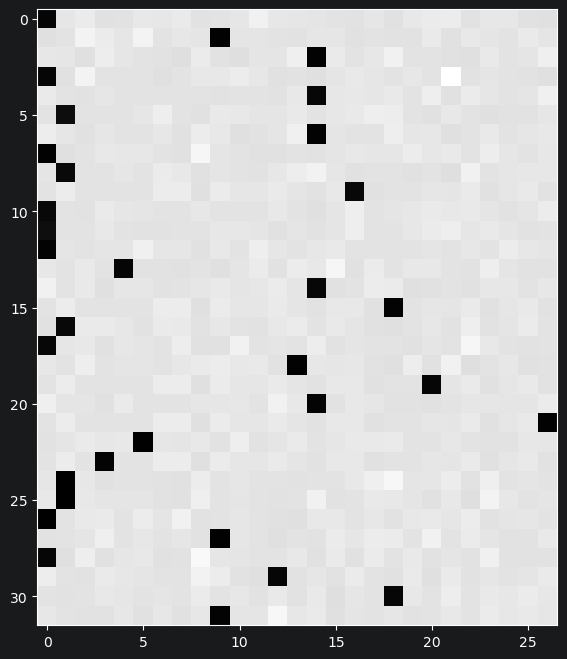

In [146]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')

In [147]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bn_gain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bn_bias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [148]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
dhprebn = bn_gain * bnvar_inv / n * (n*dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact*bnraw).sum(0))
cmp('hpreact', dhpreact, hpreact)
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hpreact         | exact: True  | approx: True  | max_diff: 0.0
hprebn          | exact: False | approx: True  | max_diff: 6.984919309616089e-10


In [156]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
#with torch.no_grad():

# kick off optimization
with torch.no_grad():
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, x_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = x_train[ix], y_train[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    # loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    # YOUR CODE HERE :)
    # dC, dW1, db1, dW2, db2, dbngain, dbnbias = None, None, None, None, None, None, None
    # manual backprop
    dlogits = F.softmax(logits, dim=1)
    dlogits[range(n), Yb] -= 1.0
    dlogits /= n
    # second layer backpropagation
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1 - h**2) * dh # backprop through tanh, hpreact = y_i
    # batch norm prob
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain * bnvar_inv / n * (n*dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            ix = Xb[k, j]
            dC[ix] += demb[k, j]

    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


12297
      0/ 200000: 3.7987
  10000/ 200000: 2.1635
  20000/ 200000: 2.3825
  30000/ 200000: 2.4827
  40000/ 200000: 1.9798
  50000/ 200000: 2.3974
  60000/ 200000: 2.3548
  70000/ 200000: 2.0376
  80000/ 200000: 2.3634
  90000/ 200000: 2.1762
 100000/ 200000: 1.9697
 110000/ 200000: 2.2844
 120000/ 200000: 1.9609
 130000/ 200000: 2.3304
 140000/ 200000: 2.3610
 150000/ 200000: 2.0980
 160000/ 200000: 1.9402
 170000/ 200000: 1.8183
 180000/ 200000: 2.0466
 190000/ 200000: 1.9278


In [157]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

TypeError: all() received an invalid combination of arguments - got (bool), but expected one of:
 * (Tensor input, *, Tensor out = None)
 * (Tensor input, tuple of ints dim = None, bool keepdim = False, *, Tensor out = None)
 * (Tensor input, int dim, bool keepdim = False, *, Tensor out = None)
 * (Tensor input, name dim, bool keepdim = False, *, Tensor out = None)


In [158]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[x_train]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [159]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (x_train, y_train),
    'val': (x_dev, y_dev),
    'test': (x_test, y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0726470947265625
val 2.10844349861145


In [ ]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [160]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzamille.
khyimili.
taty.
skaelane.
mahnen.
den.
arci.
aqui.
nellara.
chaiivan.
leigh.
ham.
join.
quint.
shoen.
alianni.
wavero.
dearyn.
kai.
eveigh.
